In [ ]:
#%pip install urllib3 xarray numpy pandas tqdm pillow matplotlib plotly seaborn scikit-learn tensorflow keras-tuner netCDF4 h5netcdf

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print("GPU Devices:", tf.config.list_physical_devices('GPU'))


2025-04-15 05:28:25.648223: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-15 05:28:25.663961: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-15 05:28:25.688476: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-15 05:28:25.688517: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-15 05:28:25.703544: I tensorflow/core/platform/cpu_feature_gua

TensorFlow version: 2.16.2
Num GPUs Available: 1
GPU Devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2025-04-15 05:28:27.740619: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-15 05:28:27.790613: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-15 05:28:27.795960: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [3]:
# Data Formatting
import urllib.request
import xarray as xr
import numpy as np
import pandas as pd
import netCDF4
import h5netcdf
from tqdm import tqdm
import os
from PIL import Image

# Data Viz
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# Data Processing
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

# CNN + LSTM
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

import pickle

Number of images: 901
Number of ENSO Intensity values: 901
First image shape: (240, 320, 3)
First ENSO Intensity value: [0. 0. 1.]


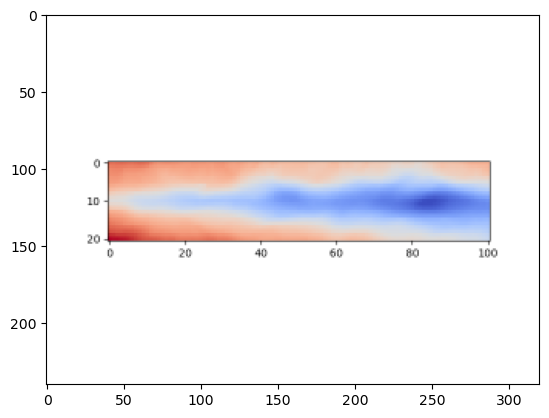

In [4]:
#a3

#path = '/content/drive/MyDrive/EASAI/A3/'
i=900

#with open(path+'sst_dataset.pkl', 'rb') as f:

with open('sst_dataset.pkl', 'rb') as f:

  X, y = pickle.load(f)
print(f'Number of images: {len(X)}')
print(f'Number of ENSO Intensity values: {len(y)}')
first_image = X[i]
print(f'First image shape: {first_image.shape}')
print(f'First ENSO Intensity value: {y[i]}')
plt.imshow(first_image)
plt.show()



In [5]:
def create_sequences(X, y, seq_length):
    X_seq = []
    y_seq = []
    for i in range(len(X) - seq_length + 1):
        X_seq.append(X[i:i + seq_length])
        y_seq.append(y[i + seq_length - 1])  # Label = last image in sequence
    return np.array(X_seq), np.array(y_seq)

In [6]:
def build_cnn_lstm_model(input_shape, num_classes):
    model = Sequential()
    model.add(TimeDistributed(Conv2D(32, (3, 3), activation='relu'), input_shape=input_shape))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))
    model.add(TimeDistributed(Conv2D(64, (3, 3), activation='relu')))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))
    model.add(TimeDistributed(Flatten()))
    model.add(LSTM(64))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    model.summary()

    model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [7]:
def plot_loss_acc_and_r2(model, history, X_test, y_test):
    train_loss = history.history['loss']
    val_loss = history.history.get('val_loss')
    train_acc = history.history.get('accuracy')
    val_acc = history.history.get('val_accuracy')
    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label='Train Loss')
    if val_loss: plt.plot(epochs, val_loss, label='Val Loss')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    if train_acc: plt.plot(epochs, train_acc, label='Train Accuracy')
    if val_acc: plt.plot(epochs, val_acc, label='Val Accuracy')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Predict and compute R²
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    print(f"R² Score on Test Data: {r2:.4f}")

In [ ]:
#cnn lstm   data batches
seq_length = 5
X_seq, y_seq = create_sequences(X, y, seq_length=seq_length)



#Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)


2025-04-15 05:28:31.775123: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-15 05:28:31.780053: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-15 05:28:31.783115: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed (TimeDist  (None, 5, 238, 318, 32)   896       
 ributed)                                                        
                                                                 
 time_distributed_1 (TimeDi  (None, 5, 119, 159, 32)   0         
 stributed)                                                      
                                                                 
 time_distributed_2 (TimeDi  (None, 5, 117, 157, 64)   18496     
 stributed)                                                      
                                                                 
 time_distributed_3 (TimeDi  (None, 5, 58, 78, 64)     0         
 stributed)                                                      
                                                                 
 time_distributed_4 (TimeDi  (None, 5, 289536)         0

2025-04-15 05:28:54.857067: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1744694936.905767   23733 service.cc:145] XLA service 0x7f3140126820 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744694936.905808   23733 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2025-04-15 05:28:56.912087: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1744694936.979385   23733 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-04-15 05:28:57.372672: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.64GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there coul

 1/17 [>.............................] - ETA: 6:08 - loss: 1.0601 - accuracy: 0.5294

2025-04-15 05:29:01.060988: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.64GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-04-15 05:29:01.758050: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.73GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-04-15 05:29:02.612253: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 6.38GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-04-15 05:29:02.612314: W external/local_tsl/tsl/framework/bfc_

 2/17 [==>...........................] - ETA: 52s - loss: 1.2729 - accuracy: 0.4853 

2025-04-15 05:29:03.025131: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.85GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


17/17 [==============================] - 40s 1s/step - loss: 1.1993 - accuracy: 0.3333 - val_loss: 1.1968 - val_accuracy: 0.2569
Epoch 2/150
17/17 [==============================] - 10s 621ms/step - loss: 1.1520 - accuracy: 0.3229 - val_loss: 1.1434 - val_accuracy: 0.2569
Epoch 3/150
17/17 [==============================] - 8s 452ms/step - loss: 1.1201 - accuracy: 0.3560 - val_loss: 1.1224 - val_accuracy: 0.2569
Epoch 4/150
17/17 [==============================] - 8s 454ms/step - loss: 1.1274 - accuracy: 0.3473 - val_loss: 1.1220 - val_accuracy: 0.2569
Epoch 5/150
17/17 [==============================] - 8s 454ms/step - loss: 1.1225 - accuracy: 0.3455 - val_loss: 1.1113 - val_accuracy: 0.2569
Epoch 6/150
17/17 [==============================] - 8s 452ms/step - loss: 1.1094 - accuracy: 0.3735 - val_loss: 1.1035 - val_accuracy: 0.2569
Epoch 7/150
17/17 [==============================] - 7s 429ms/step - loss: 1.1126 - accuracy: 0.3647 - val_loss: 1.0963 - val_accuracy: 0.2569
Epoch 8/150


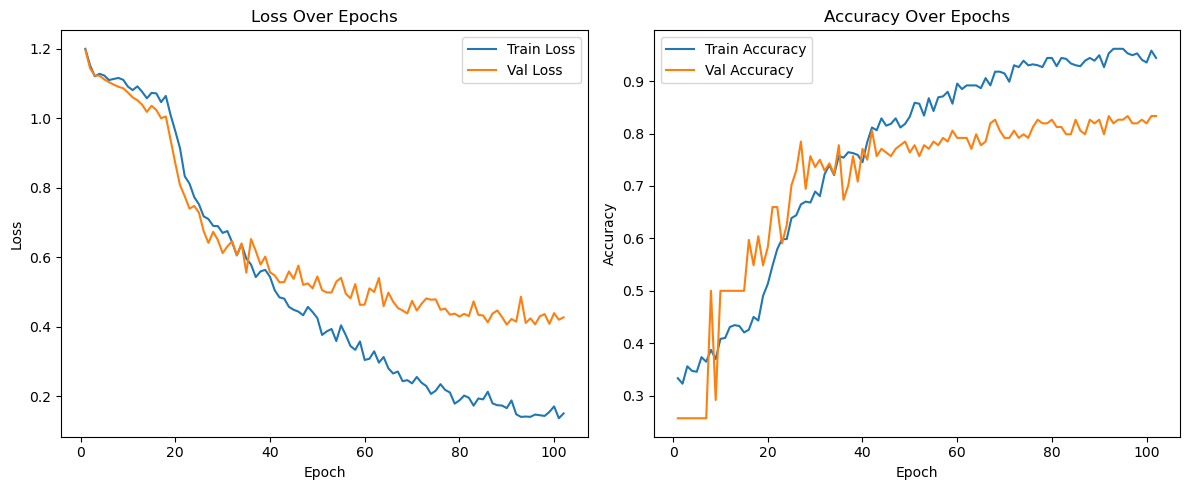

6/6 [==============================] - 4s 437ms/step
R² Score on Test Data: 0.6047


In [9]:
#model

input_shape = X_train.shape[1:]  # (4, 240, 320, 3)
num_classes = y_train.shape[1]

model = build_cnn_lstm_model(input_shape, num_classes)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=False,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=17*2,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Step 7: Evaluate and visualize
plot_loss_acc_and_r2(model, history, X_test, y_test)